# Loading and Visualization

In this section, we illustrate how to load and visualize the pseudoPAGES2k dataset with `cfr`.

Required data to complete this tutorial:

- pseudoPAGES2k: [ppwn_SNRinf_rta.nc](https://github.com/fzhu2e/paper-pseudoPAGES2k/raw/main/data/ppwn_SNRinf_rta.nc)

In [42]:
%load_ext autoreload
%autoreload 2

%pip install cartopy
%pip install cfr
%pip install requests
%pip install nbformat>=4.2.0

import cfr
print(cfr.__version__)
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
2026.6.25.14


## Load the pseudoPAGES2k dataset with `xarray`

By default, we may load a netCDF file with `xarray` to have a check of the data structure:

In [43]:
ds = xr.open_dataset('./data/ppwn_SNRinf_rta.nc', use_cftime=True)
ds

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 1156)
Coordinates:
  * time     (time) object 9kB 0850-01-01 00:00:00 ... 2005-01-01 00:00:00
Data variables: (12/558)
    NAm_153  (time) float64 9kB ...
    NAm_165  (time) float64 9kB ...
    Asi_178  (time) float64 9kB ...
    Asi_174  (time) float64 9kB ...
    Asi_198  (time) float64 9kB ...
    NAm_145  (time) float64 9kB ...
    ...       ...
    Ocn_169  (time) float64 9kB ...
    Asi_201  (time) float64 9kB ...
    Asi_179  (time) float64 9kB ...
    Arc_014  (time) float64 9kB ...
    Ocn_071  (time) float64 9kB ...
    Ocn_072  (time) float64 9kB ...

In [44]:
ds['Arc_076']

<xarray.DataArray 'Arc_076' (time: 1156)> Size: 9kB
[1156 values with dtype=float64]
Coordinates:
  * time     (time) object 9kB 0850-01-01 00:00:00 ... 2005-01-01 00:00:00
Attributes:
    lat:         62.917
    lon:         290.117
    elev:        nan
    ptype:       lake.varve_thickness
    dt:          1.0
    time_name:   Time
    time_unit:   yr
    value_name:  temperature
    value_unit:  degC

We see that this netCDF file has multiple data variables named after **proxy IDs**.
Each variable comes with the below fundamental attributes:

- lat: the latitude of the site
- lon: the longitude of the site
- ptype: the proxy type
- dt: step of the time axis, i.e., temporal resolution
- time_name: name of the time axis
- time_unit: unit of the time axis
- value_name: unit of the value axis
- value_unit: unit of the value axis

With this certain format, the netCDF file is `cfr` ready.

## Load the pseudoPAEGS2k dataset with `cfr`

The `cfr.ProxyDatabase` class comes with a `.load_nc()` method that can help us load a proxy database from a netCDF file following the certain format shown above:

In [45]:
# load the pseudoPAGES2k database from a netCDF file

# load from a local copy
# pdb = cfr.ProxyDatabase().load_nc('./data/ppwn_SNRinf_rta.nc')

# load from the cloud
pdb = cfr.ProxyDatabase().fetch('pseudoPAGES2k/ppwn_SNRinf_rta')

## Visualize and check the pseudoPAGES2k dataset by using **proxy IDs** on an interactive map

One may ask "How do I know the proxy IDs?"

Once the netCDF file is loaded as a `cfr.ProxyDatabase`, we can easily visualize the dataset with the `.plot().

A `cfr.ProxyDatabase` object also comes with a `.plotly()` method that can help us check **proxy IDs** on an interactive map.
It will display an interactive map, and by hovering the mouse over each site marker, one may check the metadata of a specific site, including:

- pid (proxy ID)
- ptype
- lat
- lon

In [46]:
pdb.plotly()

We may also plot map along with the count of the records:

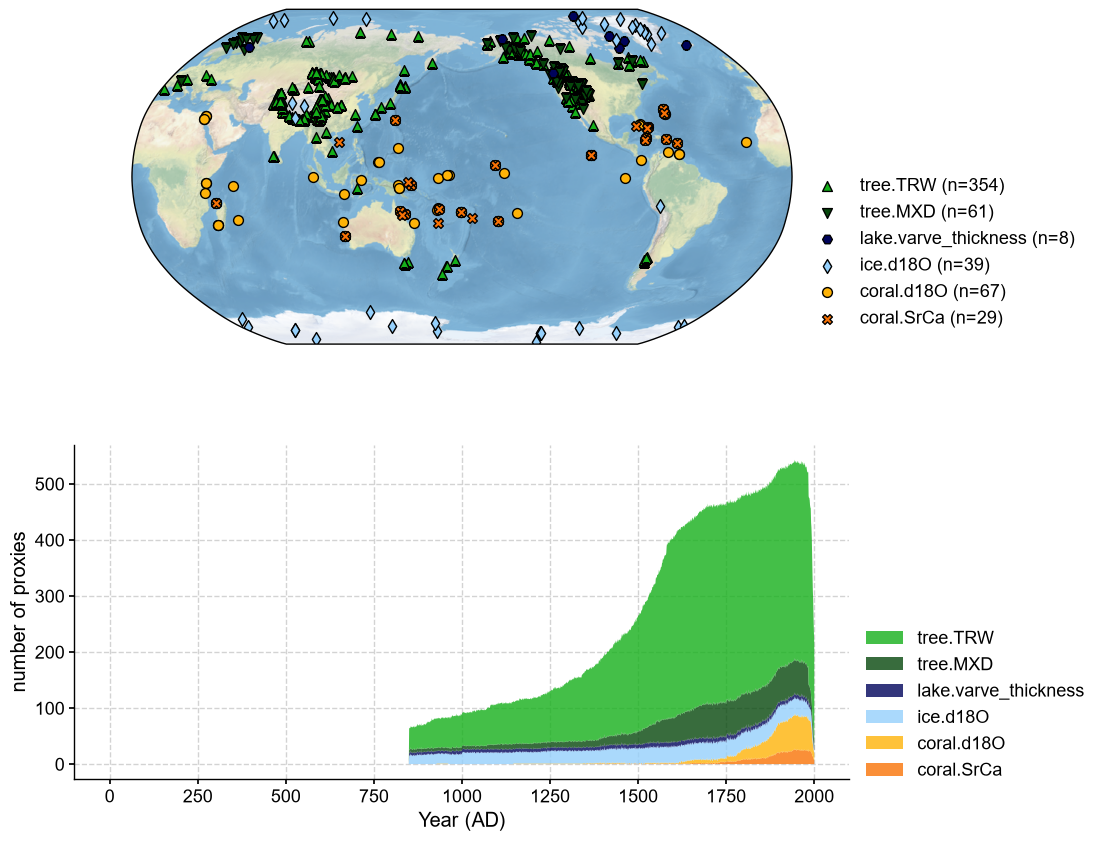

In [47]:
fig, ax = pdb.plot(plot_count=True)

Since the dataset starts from 850 AD, we may adjust the x-axis utilizing the `matplotlib` methods:

(800.0, 2000.0)

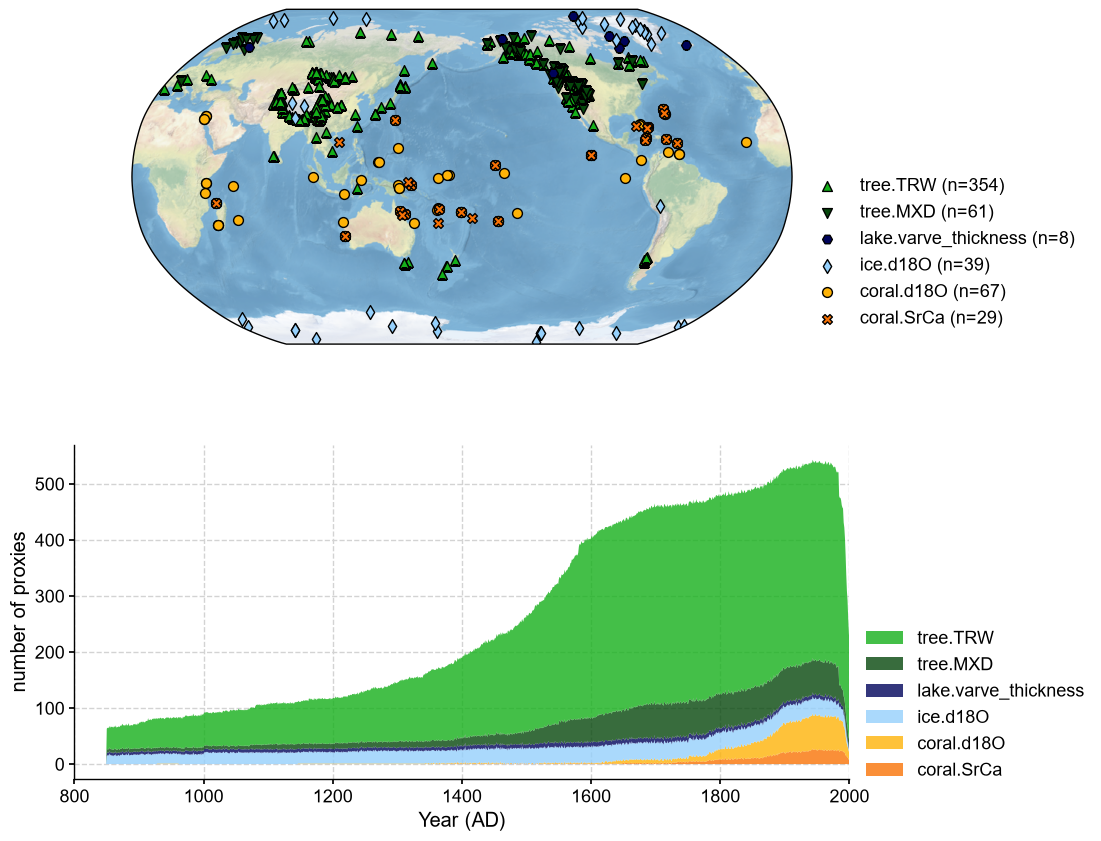

In [48]:
fig, ax = pdb.plot(plot_count=True)
ax['count'].set_xlim(800, 2000)

## Access and visualize a specific record

A specific record can be accessed by its **proxy ID**:

In [49]:
pobj = pdb['NAm_001']
pobj

This returned object is defined by `cfr.ProxyRecord`, which comes with several attributes such as:
- time: the time axis
- value: the value axis
- lat: the latitude of the site
- lon: the longitude of the site
- (... other metadata)

For instance, to access the record series:

In [50]:
print('time axis:', pobj.time)
print('value axis:', pobj.value)

time axis: [ 850.  851.  852. ... 2000. 2001. 2002.]
value axis: [1.06636798 0.86741749 0.87185387 ... 0.81825943 0.58718452 0.85097093]


Now that we have the `cfr.ProxyRecord` object, we can easily visualize the record utilizing the `.plot()` method:

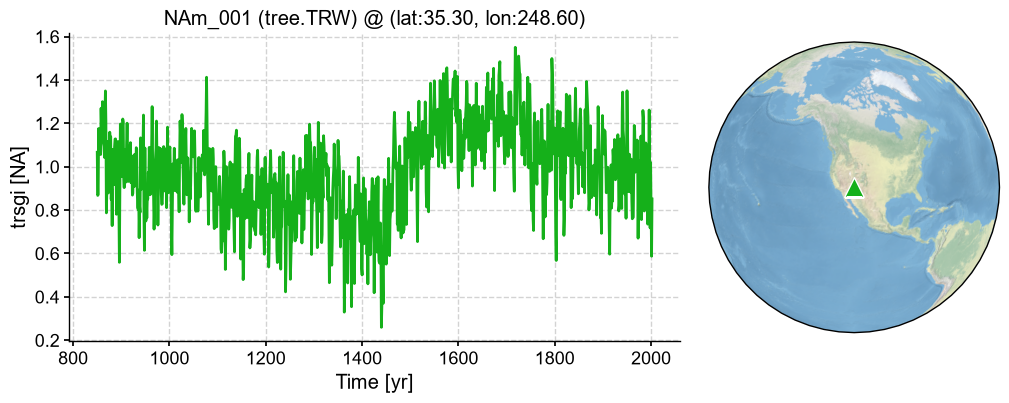

In [51]:
fig, ax = pobj.plot()

We may **slice the record** to zoom in and out.
For instance, let us check the instrumental period:

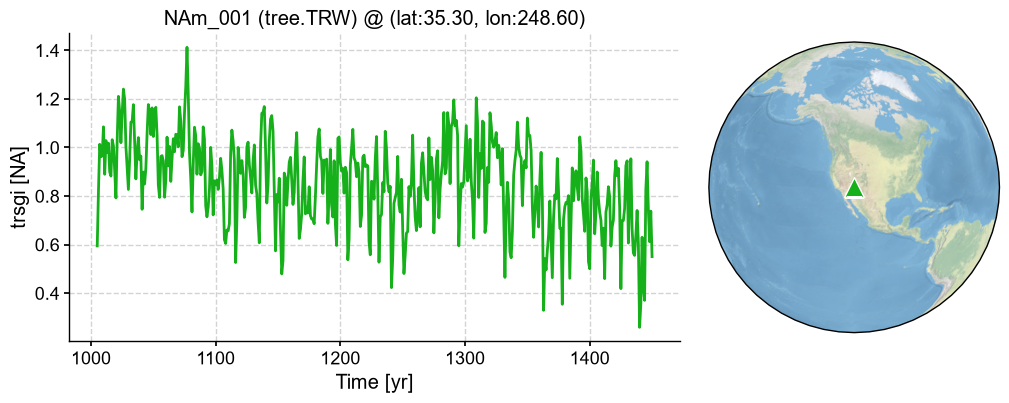

In [52]:
fig, ax = pobj.slice([1005, 1450]).plot()

We may also slice with a shortcut using strings of years:

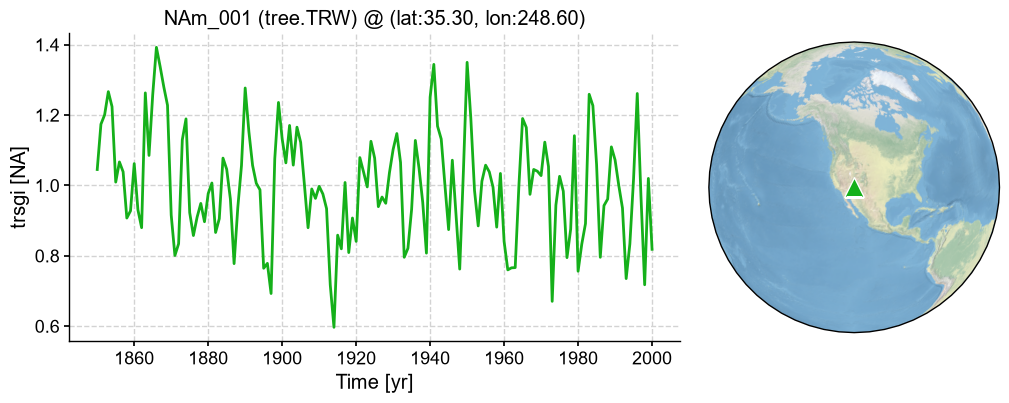

In [53]:
fig, ax = pobj['1850':'2000'].plot()

This shortcut also supports time step.
For instance, to display the data points every 10 years between 1850 AD and 2000 AD:

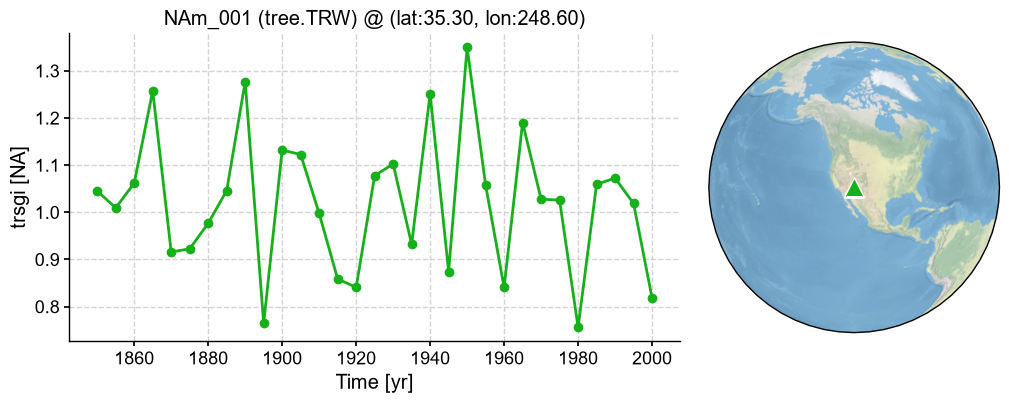

In [54]:
fig, ax = pobj['1850':'2000':'5'].plot(marker='o')

# Proxy System Model (PSM) by Univariate linear regression

It is a mathematical or physical model used to understand how environmental changes are recorded by a geological or biological archive.

In this section, we introduce the default PSM in `cfr` based on univariate linear regression.
It can be applied to any proxy type that is believed to have a univariate linear relationship with a certain climate variable.
It also supports a seasonality searching procedure to help determine the seasonality of a specific site.

For instance, this PSM can be applied to the `tree.MXD` records, which we believe have high linear correlation with the local temperature condition over a growing season.

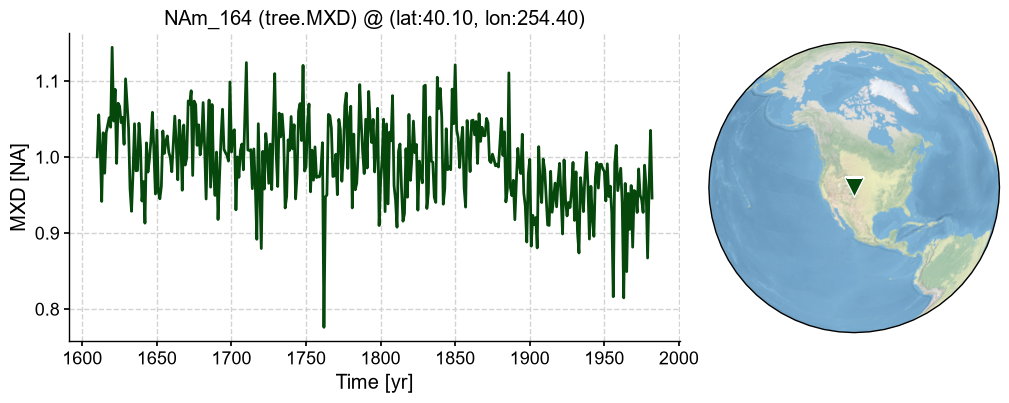

In [55]:
pobj = pdb.records['NAm_164']
fig, ax = pobj.plot()

### Model

Its job is to mathematically simulate how one single environmental variable (usually temperature or precipitation) translates into a physical proxy measurement (like tree-ring width or coral $\delta^{18}\text{O}$).

The Mathematical FrameworkIn a standard univariate linear PSM, the proxy value is modeled as a straight-line function of the climate variable, plus random environmental/measurement noise:
$$P_{t} = \beta_{0} + \beta_{1} \cdot C_{t} + \epsilon$$


##### Load climate-model fields

Load model temperature and precipitation fields from the iCESM past1000 historical simulation.

In [56]:
model_tas = cfr.ClimateField().fetch('iCESM_past1000historical/tas')
model_pr = cfr.ClimateField().fetch('iCESM_past1000historical/pr')

>>> The target file seems existed at: ./data/tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc . Loading from it instead of downloading ...
>>> The target file seems existed at: ./data/pr_sfc_Amon_iCESM_past1000historical_085001-200512.nc . Loading from it instead of downloading ...


Load model temperature and precipitation fields from the iCESM past1000 historical simulation.

In [57]:
model_pr.da

<xarray.DataArray 'pr' (time: 13872, lat: 96, lon: 144)> Size: 767MB
array([[[5.3656402e-07, 5.3651877e-07, 5.3656402e-07, ...,
         5.3651877e-07, 5.3656402e-07, 5.3656402e-07],
        [5.6582650e-07, 5.4642481e-07, 5.3039008e-07, ...,
         5.5696472e-07, 5.7421937e-07, 5.7034282e-07],
        [1.2490789e-06, 1.2078700e-06, 1.1426664e-06, ...,
         1.0885065e-06, 1.1210977e-06, 1.1950800e-06],
        ...,
        [6.3864509e-06, 6.3524171e-06, 6.2489103e-06, ...,
         6.7236329e-06, 6.7695423e-06, 6.6178945e-06],
        [8.0635336e-06, 8.2520573e-06, 8.3249915e-06, ...,
         7.4809509e-06, 7.6837814e-06, 7.9719775e-06],
        [4.0183381e-06, 4.0183654e-06, 4.0184218e-06, ...,
         4.0182667e-06, 4.0182590e-06, 4.0183108e-06]],

       [[2.0539692e-06, 2.0539692e-06, 2.0539692e-06, ...,
         2.0539692e-06, 2.0539692e-06, 2.0539692e-06],
        [3.1072011e-06, 2.9498874e-06, 2.8696384e-06, ...,
         3.4914701e-06, 3.3995072e-06, 3.2553696e-06],
        [3.6575125e-06, 3.3436265e-06, 3.1105342e-06, ...,
         4.5944275e-06, 4.3744508e-06, 4.0360160e-06],
...
         5.8137994e-06, 5.9868175e-06, 6.3147058e-06],
        [4.8919364e-06, 4.9042906e-06, 5.0902959e-06, ...,
         4.7235976e-06, 4.7740505e-06, 4.7601052e-06],
        [5.1131842e-06, 5.1131842e-06, 5.1131842e-06, ...,
         5.1131842e-06, 5.1131842e-06, 5.1131842e-06]],

       [[7.1005695e-07, 7.1005695e-07, 7.1005695e-07, ...,
         7.1005695e-07, 7.1005695e-07, 7.1005695e-07],
        [1.0973795e-06, 1.0779764e-06, 1.0755907e-06, ...,
         1.1956587e-06, 1.1627161e-06, 1.1283872e-06],
        [1.9660624e-06, 1.8770792e-06, 1.8267003e-06, ...,
         2.2019376e-06, 2.0961058e-06, 2.1013741e-06],
        ...,
        [6.8181494e-06, 6.8738327e-06, 7.0795641e-06, ...,
         6.1406499e-06, 6.4202486e-06, 6.5805498e-06],
        [6.4912620e-06, 6.7894211e-06, 7.0785791e-06, ...,
         5.7969082e-06, 6.0140069e-06, 6.2037798e-06],
        [3.3558911e-06, 3.3558595e-06, 3.3558242e-06, ...,
         3.3561346e-06, 3.3560252e-06, 3.3559493e-06]]],
      shape=(13872, 96, 144), dtype=float32)
Coordinates:
  * time     (time) object 111kB 0850-01-17 00:00:00 ... 2005-12-17 00:00:00
  * lat      (lat) float32 384B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:  Total mass precip rate of H216O
    units:      kg m-2 s-1

In [58]:
import numpy as np

print(np.median(np.diff(model_tas.da.lat)))
print(np.median(np.diff(model_tas.da.lon)))


1.8947372
2.5


### Instrumental observations

CRUTSv4.07 (Climatic Research Unit Time-Series, version 4.07) is a high-resolution gridded climate dataset that tracks global month-by-month climate variations from January 1901 to December 2022 https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.07/

Key SpecificationsSpatial Resolution: 
- 0.5° latitude by 0.5° longitude grid, covering all global land domains except Antarctica.
- Temporal Coverage: Monthly historical data covering 122 years (1901–2022).
- Methodology: It utilizes an Angular-Distance Weighting (ADW) interpolation method to turn raw weather station observations into a complete, seamless global grid.

The Mathematical FrameworkIn a standard univariate linear PSM, the proxy value is modeled as a straight-line function of the climate variable, plus random environmental/measurement noise:
$$P_{t}=\beta _{0}+\beta _{1}\cdot C_{t}+\epsilon$$
- $P_{t}$: The predicted Proxy value at time
- $C_{t}$: The input Climate variable (e.g., local surface temperature).
- $\beta _{0}$: The intercept (the base state of the proxy).
- $\beta _{1}$: The slope (the sensitivity of the proxy to the climate change).
- $\epsilon$: The residual error (noise), representing non-climatic influences

In [59]:
obs_tas = cfr.ClimateField().fetch('CRUTSv4.07/tas', vn='tmp')
obs_pr = cfr.ClimateField().fetch('CRUTSv4.07/pr', vn='pre')

>>> The target file seems existed at: ./data/cru_ts4.07.1901.2022.tmp.dat.nc.gz . Loading from it instead of downloading ...
>>> The target file seems existed at: ./data/cru_ts4.07.1901.2022.pre.dat.nc.gz . Loading from it instead of downloading ...


#### Standardize observational variable names

Rename the downloaded observational variables to `tas` for temperature and `pr` for precipitation.

In [60]:
import numpy as np

obs_tas = obs_tas.rename('tas')
obs_pr = obs_pr.rename('pr')

Visualize the CRUTSv4.07 temperature field using contour levels from −40 °C to 40 °C.

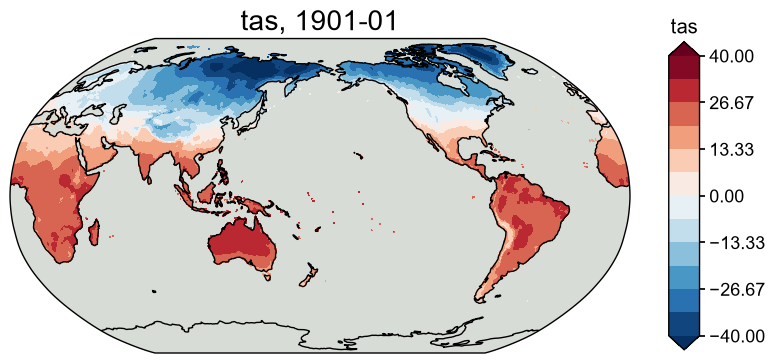

In [61]:
fig, ax = obs_tas.plot(levels=np.linspace(-40, 40, 13), cmap='RdBu_r')

#### Wrap temperature longitudes

Convert the temperature field longitudes to a consistent coordinate convention.

In [62]:
obs_tas_new = obs_tas.wrap_lon()

Verify the coordinates after adjusting the longitude convention.

In [63]:
obs_tas_new.da.coords

Coordinates:
  * time     (time) object 12kB 1901-01-16 00:00:00 ... 2022-12-16 00:00:00
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8

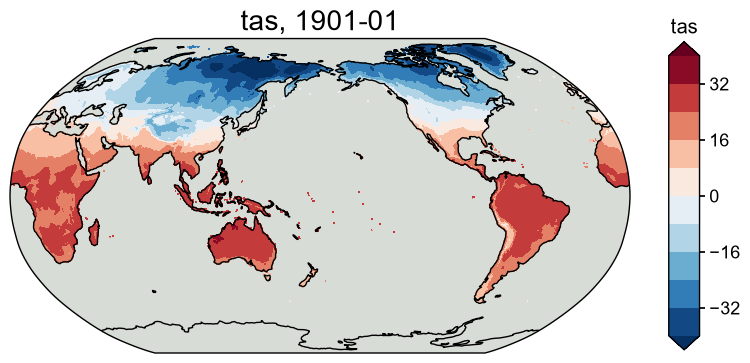

In [64]:
fig, ax = obs_tas_new.plot(levels=np.linspace(-40, 40, 11))

### Inspect precipitation coordinates

Display the original coordinates of the observational precipitation field.

In [65]:
obs_pr.da.coords

Coordinates:
  * time     (time) object 12kB 1901-01-16 00:00:00 ... 2022-12-16 00:00:00
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8

#### Wrap precipitation longitudes

Convert the precipitation field longitudes to the same convention as the temperature field.

In [66]:
obs_pr_new = obs_pr.wrap_lon()

Verify the precipitation coordinates after longitude adjustment.

In [67]:
obs_pr_new.da.coords

Coordinates:
  * time     (time) object 12kB 1901-01-16 00:00:00 ... 2022-12-16 00:00:00
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8

## Get climate data for a specific `ProxyRecord`

In [68]:
%%time

pobj.del_clim()
pobj.get_clim(model_tas, tag='model')
pobj.get_clim(model_pr, tag='model')
pobj.get_clim(obs_tas_new, tag='obs')
pobj.get_clim(obs_pr_new, tag='obs')

CPU times: total: 2.53 s
Wall time: 8.26 s


In [69]:
pobj.clim['obs.tas'].da

<xarray.DataArray 'tas' (time: 1464)> Size: 6kB
array([ -9.5     , -11.8     ,  -8.1     , ...,   2.5     ,  -6.3     ,
        -9.400001], shape=(1464,), dtype=float32)
Coordinates:
  * time     (time) object 12kB 1901-01-16 00:00:00 ... 2022-12-16 00:00:00
    lat      float32 4B 40.25
    lon      float32 4B 254.2
Attributes:
    long_name:                   near-surface temperature
    units:                       degrees Celsius
    correlation_decay_distance:  1200.0

## Create a PSM object

#### Calibrate the linear PSM

Test the candidate seasonal windows and calibrate the univariate linear proxy system model.

In [70]:
lr_mdl = cfr.psm.Linear(pobj)

In [71]:
%%time
sn_list = [
    [1,2,3,4,5,6,7,8,9,10,11,12],
    [6,7,8],
    [3,4,5,6,7,8],
    [6,7,8,9,10,11],
    [-12,1,2],
    [-9,-10,-11,-12,1,2],
    [-12,1,2,3,4,5]
]
lr_mdl.calibrate(season_list=sn_list)

CPU times: total: 1.3 s
Wall time: 1.74 s


#### Review calibration details

Inspect the fitted model parameters and diagnostics produced during calibration.

In [72]:
lr_mdl.calib_details

{'df':            proxy        tas
 time                       
 1901.0  0.882636 -10.650000
 1902.0  0.923275  -9.266666
 1903.0  0.910979 -11.433333
 1904.0  0.920307  -8.466666
 1905.0  0.880334 -10.900001
 ...          ...        ...
 1978.0  0.960235  -8.800000
 1979.0  0.867076 -12.800000
 1980.0  0.960721  -9.099999
 1981.0  1.034930  -5.733334
 1982.0  0.945962  -8.933333
 
 [82 rows x 2 columns],
 'nobs': 82.0,
 'fitR2adj': np.float64(0.02103504059217065),
 'PSMresid': time
 1901.0   -0.058533
 1902.0   -0.025130
 1903.0   -0.026092
 1904.0   -0.032282
 1905.0   -0.059526
             ...   
 1978.0    0.009390
 1979.0   -0.062845
 1980.0    0.011445
 1981.0    0.068043
 1982.0   -0.004186
 Length: 82, dtype: float64,
 'PSMmse': np.float64(0.0017280276859610638),
 'SNR': np.float64(0.1850827077604378),
 'seasonality': [-12, 1, 2]}

#### Generate the modeled proxy

Use the calibrated PSM to forward-model the proxy response from the climate data.

In [73]:
%%time
pp = lr_mdl.forward()

CPU times: total: 1 s
Wall time: 1.11 s


#### Plot the modeled proxy series

Visualize the proxy series generated by the calibrated linear PSM.

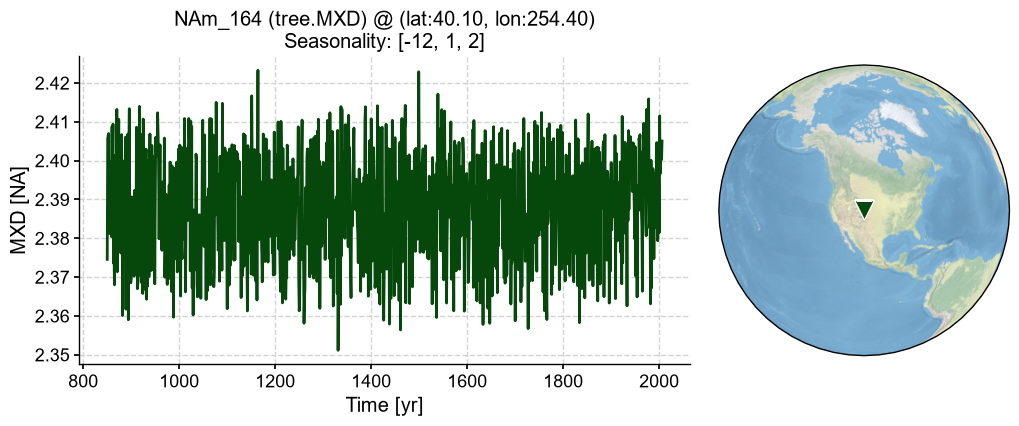

In [74]:
fig, ax = pp.plot()

# Reconstructing the tropical Pacific SST with PAGES2k and GraphEM

**Expected time to run through: ~0.5 hrs**

In this section, we illustrate the basic workflow of the Graphical Expectation-Maximization algorithm (GraphEM, [Guillot et al., 2015](https://doi.org/10.1214/14-AOAS794)) with `cfr`, conducting a reconstruction experiment with the PAGES2k dataset.
Due to the intensive computational requirement of the GraphEM method, our goal is to reconstruct the air surface temperature field only over the tropical Pacific region using coral records.

Note: `pip install "cfr[graphem]"` to enable the GraphEM method if not done before.

(800.0, 2000.0)

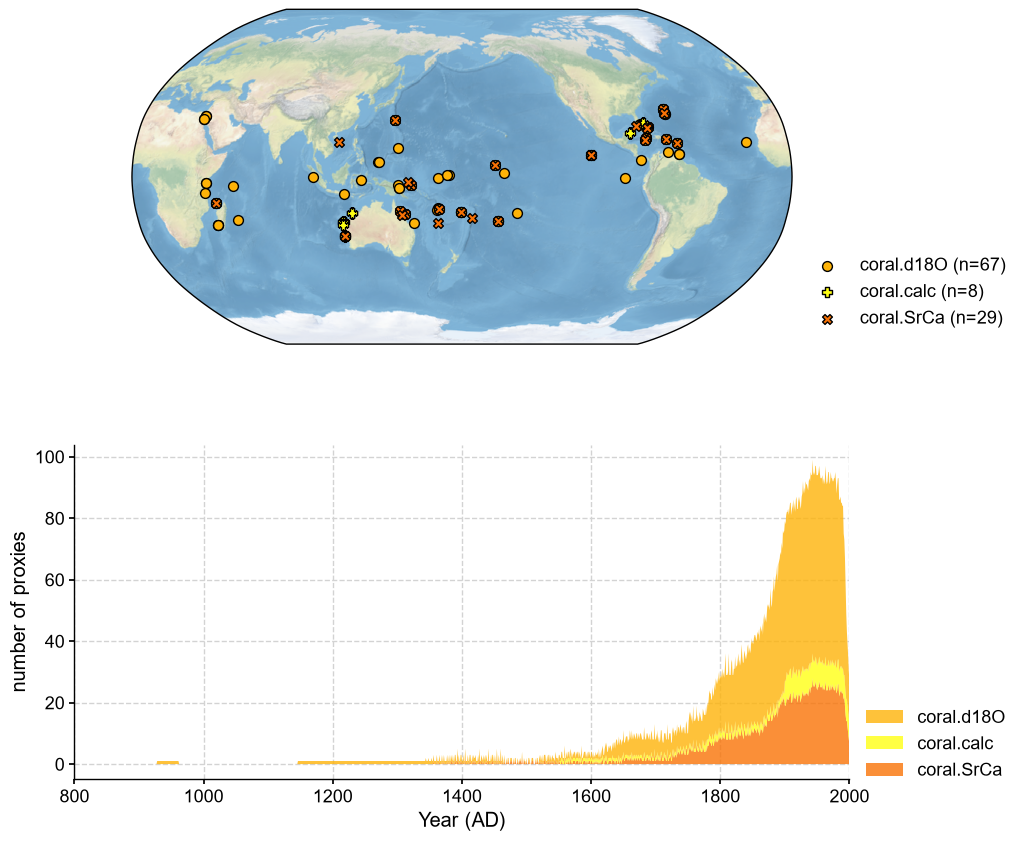

In [75]:
# create a reconstruction job object using the `cfr.ReconJob` class
job = cfr.ReconJob()

# load the pseudoPAGES2k database from a netCDF file

# load from a local copy
# job.proxydb = cfr.ProxyDatabase().load_nc('./data/ppwn_SNRinf_rta.nc')

# load from the cloud
job.load_proxydb('PAGES2kv2')

# filter the database
job.filter_proxydb(by='ptype', keys='coral')

# plot to have a check of the database
fig, ax = job.proxydb.plot(plot_count=True)
ax['count'].set_xlim(800, 2000)

### Annualize each proxy record

In [76]:
job.annualize_proxydb(months=[12, 1, 2], verbose=True)

>>> job.configs["annualize_proxydb_months"] = [12, 1, 2]
>>> job.configs["annualize_proxydb_ptypes"] = {'coral.calc', 'coral.d18O', 'coral.SrCa'}


Annualizing ProxyDatabase: 100%|██████████| 104/104 [00:06<00:00, 16.84it/s]

>>> 99 records remaining
>>> job.proxydb updated


In [77]:
job.load_clim(
    tag='obs',
    path_dict={
        'tas': 'gistemp1200_GHCNv4_ERSSTv5', # load from the cloud
    },
    rename_dict={'tas': 'tempanomaly'},
    anom_period=(1951, 1980),
    load=True,  # load the data into memeory to accelerate the later access; requires large memeory
    verbose=True,
)

>>> job.configs["obs_path"] = {'tas': 'gistemp1200_GHCNv4_ERSSTv5'}
>>> job.configs["obs_rename_dict"] = {'tas': 'tempanomaly'}
>>> job.configs["obs_anom_period"] = [1951, 1980]
>>> job.configs["obs_lat_name"] = lat
>>> job.configs["obs_lon_name"] = lon
>>> job.configs["obs_time_name"] = time
>>> The target file seems existed at: ./data/gistemp1200_GHCNv4_ERSSTv5.nc.gz . Loading from it instead of downloading ...
>>> obs variables ['tas'] loaded
>>> job.obs created
